# Lab 3 : Analyse des Jeux Olympiques — Scénarios de Visualisation

**Bibliothèques utilisées :**
[Pandas](https://pandas.pydata.org/docs/) | [Matplotlib](https://matplotlib.org/) | [Seaborn](https://seaborn.pydata.org/api.html)

---

## Contexte

On travaille avec le dataset **120 years of Olympic History** (Randi Griffin / sports-reference.com), disponible sur le [dépôt GitHub du livre](https://github.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/tree/master/datasets).

**Objectif :** identifier les **5 sports** ayant reçu le plus de médailles en **2016**, puis produire 4 visualisations :

1. Barplot — nombre de médailles dans chacun des 5 sports
2. Histogramme — distribution de l'âge des médaillés dans ces 5 sports
3. Barplot — quelles équipes nationales ont gagné le plus de médailles dans ces 5 sports
4. Barplot — poids moyen des athlètes par genre dans ces 5 sports

## Étapes

1. Télécharger le dataset et le charger en DataFrame pandas
2. Filtrer pour ne garder que les médaillés de 2016 (exclure les NaN dans `Medal`)
3. Compter les médailles par sport en 2016
4. Identifier le top 5 sports, filtrer une dernière fois le DataFrame
5. Produire les 4 graphiques demandés

In [1]:
# =====================================================
# Step 1 : Import des librairies
# =====================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<hr style="border: 2px solid black;">

## Step 2 : Chargement et exploration des données

In [2]:
# =====================================================
# Step 2 : Chargement du dataset depuis le dépôt GitHub du livre
# =====================================================
url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/athlete_events.csv"
df = pd.read_csv(url)
print(f"Shape du dataset : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Shape du dataset : (271116, 15)
Colonnes : ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Le dataset contient **271 116 lignes** et **15 colonnes**. Chaque ligne correspond à un athlète dans un événement donné. Les colonnes incluent : ID, Name, Sex, Age, Height, Weight, Team, NOC, Games, Year, Season, City, Sport, Event, Medal.

`Medal` vaut Gold/Silver/Bronze ou `NA` si l'athlète n'a pas gagné de médaille.

<hr style="border: 2px solid black;">

## Step 3 : Filtrage et identification du top 5

In [3]:
# =====================================================
# Step 3 : Filtrage — médaillés de 2016 uniquement
# =====================================================
# On exclut les NaN dans Medal → ne garder que les lignes avec une médaille
df_2016 = df[(df['Year'] == 2016) & (df['Medal'].notna())].copy()
print(f"Nombre de médaillés en 2016 : {len(df_2016)}")
print(f"Sports représentés : {df_2016['Sport'].nunique()}")
df_2016.head()

Nombre de médaillés en 2016 : 2023
Sports représentés : 34


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
158,62,Giovanni Abagnale,M,21.0,198.0,90.0,Italy,ITA,2016 Summer,2016,Summer,Rio de Janeiro,Rowing,Rowing Men's Coxless Pairs,Bronze
161,65,Patimat Abakarova,F,21.0,165.0,49.0,Azerbaijan,AZE,2016 Summer,2016,Summer,Rio de Janeiro,Taekwondo,Taekwondo Women's Flyweight,Bronze
175,73,Luc Abalo,M,31.0,182.0,86.0,France,FRA,2016 Summer,2016,Summer,Rio de Janeiro,Handball,Handball Men's Handball,Silver
450,250,Saeid Morad Abdevali,M,26.0,170.0,80.0,Iran,IRI,2016 Summer,2016,Summer,Rio de Janeiro,Wrestling,"Wrestling Men's Middleweight, Greco-Roman",Bronze
794,455,Denis Mikhaylovich Ablyazin,M,24.0,161.0,62.0,Russia,RUS,2016 Summer,2016,Summer,Rio de Janeiro,Gymnastics,Gymnastics Men's Team All-Around,Silver


In [4]:
# =====================================================
# Step 4 : Top 5 sports par nombre de médailles en 2016
# =====================================================
medals_by_sport = df_2016['Sport'].value_counts()
print("Médailles par sport (top 10) :")
print(medals_by_sport.head(10))

top5_sports = medals_by_sport.head(5).index.tolist()
print(f"\nTop 5 : {top5_sports}")

# Filtrer pour ne garder que ces 5 sports
df_top5 = df_2016[df_2016['Sport'].isin(top5_sports)].copy()
print(f"Lignes restantes après filtrage : {len(df_top5)}")

Médailles par sport (top 10) :
Sport
Athletics       192
Swimming        191
Rowing          144
Football        106
Hockey           99
Handball         89
Cycling          84
Canoeing         82
Water Polo       78
Rugby Sevens     74
Name: count, dtype: int64

Top 5 : ['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']
Lignes restantes après filtrage : 732


<hr style="border: 2px solid black;">

## Step 5 : Visualisations

### Graphique 1 — Barplot : nombre de médailles par sport

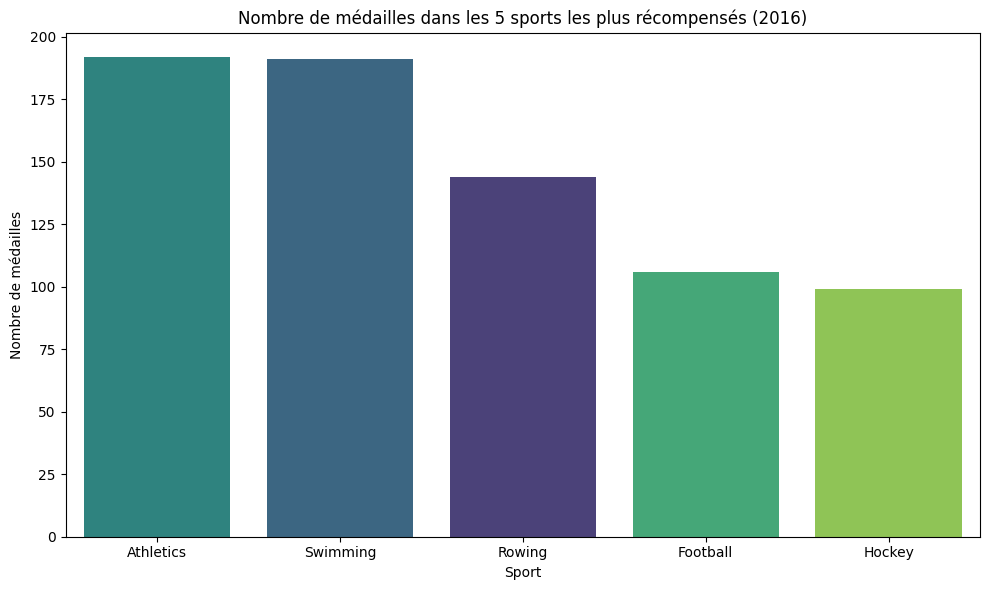

In [5]:
# =====================================================
# Graphique 1 : Nombre de médailles par sport (top 5)
# =====================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_top5, x='Sport', hue='Sport', order=top5_sports,
              palette='viridis', legend=False, ax=ax)
ax.set_title('Nombre de médailles dans les 5 sports les plus récompensés (2016)')
ax.set_xlabel('Sport')
ax.set_ylabel('Nombre de médailles')
plt.tight_layout()
plt.show()

**Observation :**
- Athletics et Swimming dominent largement avec ~190 médailles chacun.
- Rowing arrive en 3e position (~145), suivi de Football et Hockey (~100 chacun).
- C'est logique : Athletics et Swimming comptent énormément d'épreuves individuelles, donc beaucoup de médailles distribuées. Les sports d'équipe (Football, Hockey) distribuent moins de médailles malgré beaucoup de participants.

### Graphique 2 — Histogramme : distribution de l'âge des médaillés

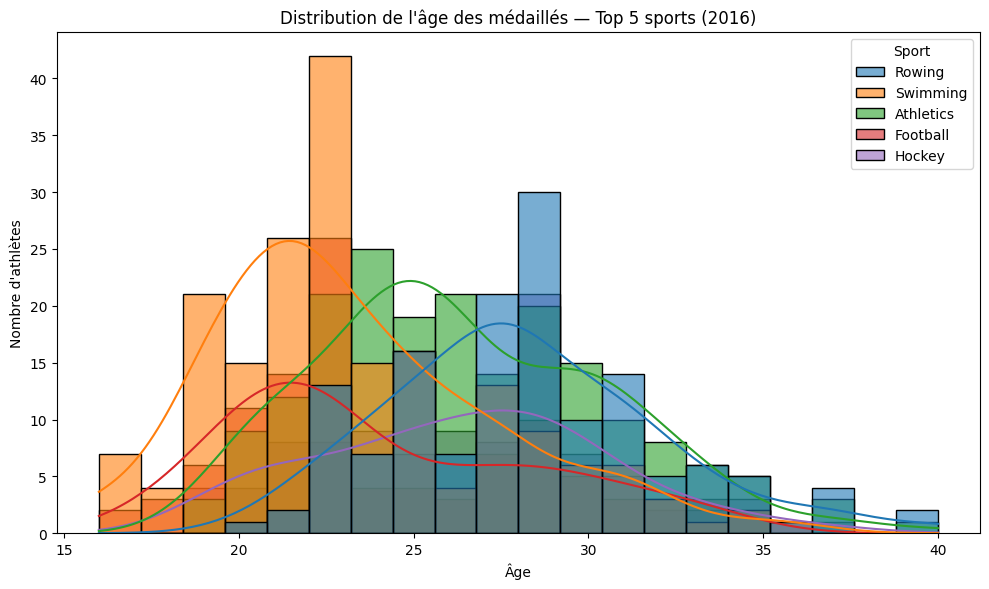

In [6]:
# =====================================================
# Graphique 2 : Distribution de l'âge des médaillés (top 5 sports)
# =====================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_top5, x='Age', hue='Sport', kde=True, bins=20, alpha=0.6, ax=ax)
ax.set_title('Distribution de l\'âge des médaillés — Top 5 sports (2016)')
ax.set_xlabel('Âge')
ax.set_ylabel('Nombre d\'athlètes')
plt.tight_layout()
plt.show()

**Observation :**
- La majorité des médaillés ont entre 20 et 30 ans, toutes disciplines confondues.
- Swimming montre un pic net autour de 22-23 ans — les nageurs sont souvent jeunes.
- Rowing a un pic plus tardif, autour de 28-29 ans — sport qui demande maturité physique.
- Athletics a une distribution plus étalée, avec des médaillés jusqu'à 35-40 ans (épreuves d'endurance type marathon).
- Football et Hockey présentent des distributions similaires centrées vers 25-28 ans.

### Graphique 3 — Barplot : médailles par équipe nationale

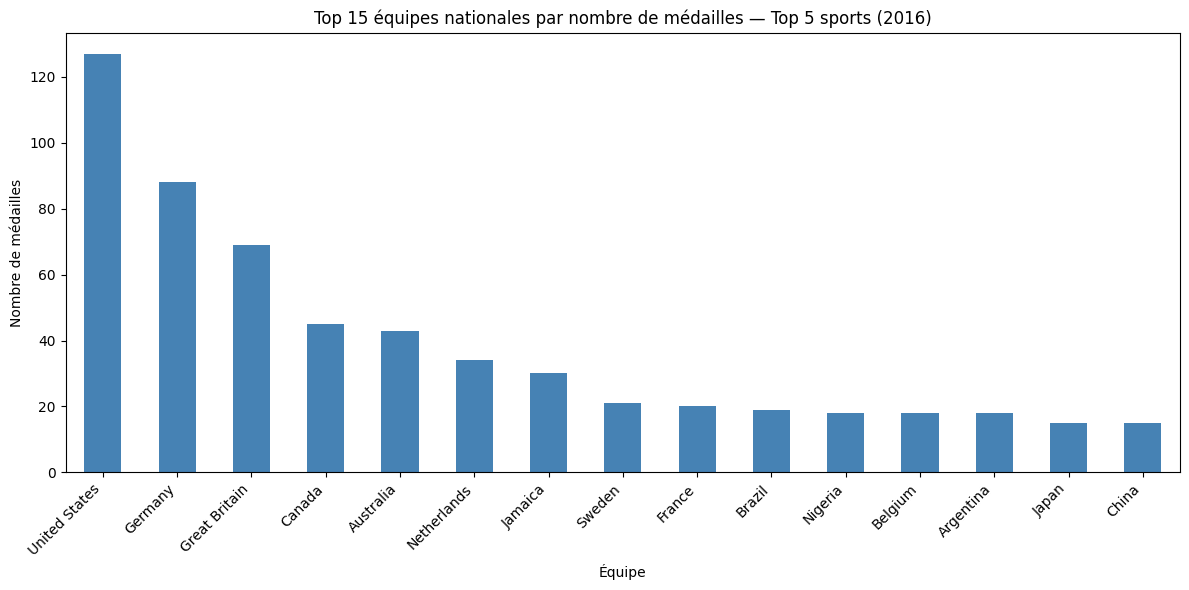

In [7]:
# =====================================================
# Graphique 3 : Médailles par équipe nationale (top 5 sports)
# =====================================================
team_medals = df_top5['Team'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
team_medals.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Top 15 équipes nationales par nombre de médailles — Top 5 sports (2016)')
ax.set_xlabel('Équipe')
ax.set_ylabel('Nombre de médailles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation :**
- Les États-Unis dominent largement (~127 médailles), portés par leur force en Athletics et Swimming.
- L'Allemagne est 2e (~88), suivie de la Grande-Bretagne (~69), du Canada (~45) et de l'Australie (~43).
- Jamaica (~30) apparaît grâce à l'Athletics (sprint). Brésil, Argentine et Nigéria doivent leur place aux sports d'équipe — chaque joueur de l'équipe = 1 médaille comptée, ce qui gonfle les chiffres pour Football et Hockey.

### Graphique 4 — Barplot : poids moyen par genre

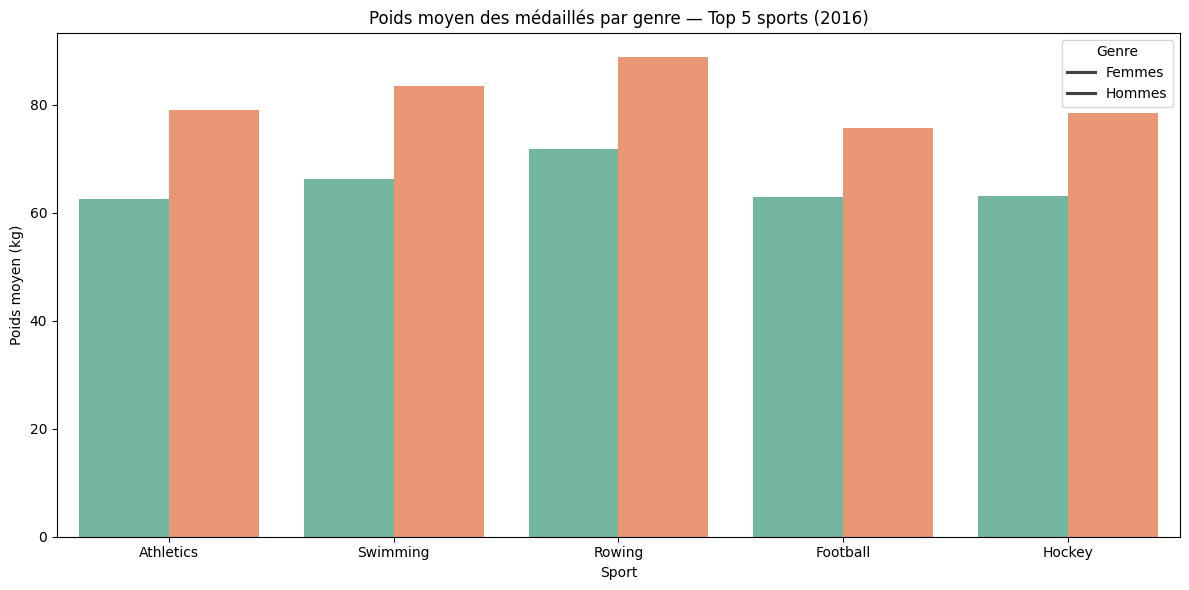

In [8]:
# =====================================================
# Graphique 4 : Poids moyen par genre dans les top 5 sports
# =====================================================
avg_weight = df_top5.groupby(['Sport', 'Sex'])['Weight'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=avg_weight, x='Sport', y='Weight', hue='Sex',
            order=top5_sports, palette='Set2', ax=ax)
ax.set_title('Poids moyen des médaillés par genre — Top 5 sports (2016)')
ax.set_xlabel('Sport')
ax.set_ylabel('Poids moyen (kg)')
ax.legend(title='Genre', labels=['Femmes', 'Hommes'])
plt.tight_layout()
plt.show()

**Observation :**
- L'écart de poids hommes/femmes est constant autour de 10-15 kg dans tous les sports.
- Rowing a les athlètes les plus lourds en moyenne (~72 kg femmes, ~89 kg hommes) — logique pour un sport de puissance.
- Swimming et Athletics montrent des poids similaires, autour de ~63 kg (F) et ~80 kg (M).
- Football et Hockey sont proches en termes de poids moyen, autour de ~63 kg (F) et ~77 kg (M).